# LOAD LIBRARIES

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import math
import json
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
import shap
from diive.core.io.files import save_parquet, load_parquet
from datetime import datetime

# CONFIGURATION

In [49]:
START_DATE, END_DATE = '2023-11-08', '2024-08-21'
TARGET_FLUX = 'FN2O'
N_FOLDS = 10
MODEL_TYPE = 'XGBoost'  # Options: 'RandomForest' or 'XGBoost'
CROSSVAL_SPLIT = 'time_blocks_eliza' # options: 'shuffle' or 'kfold' or 'custom_time_blocks' or 'time_blocks_eliza'
LOG_TRANSFORM = True
UNDERSAMPLE = False

# LOAD DATA

In [50]:
data_main = fluxes = load_parquet(filepath=r"111.1_GapFillingDataset.parquet", sanitize_timestamp=False)
data_main = data_main.loc[START_DATE:END_DATE].copy()

# Temporary fix!!!
data_main.loc[data_main['cropN_diff24h'] < 0, 'cropN_diff24h'] = 0

maindf = data_main.copy()

data_main

Loaded .parquet file 111.1_GapFillingDataset.parquet (0.076 seconds).


,prec,ta,timesince_prec,ts_0.05_gfXG,ts_0.15_gfXG,ts_0.3_gfXG,wfps_0.05_gfXG,wfps_0.15_gfXG,wfps_0.3_gfXG,timesince_soil_preparation,timesince_harvest,timesince_sowing,n_decay_linear,n_decay_logistic,n_decay_exponential,...,ts_0.3_gfXG_diff24h,ts_0.3_gfXG_diff48h,ts_0.3_gfXG_diff72h,wfps_0.05_gfXG_diff24h,wfps_0.05_gfXG_diff48h,wfps_0.05_gfXG_diff72h,wfps_0.15_gfXG_diff24h,wfps_0.15_gfXG_diff48h,wfps_0.15_gfXG_diff72h,wfps_0.3_gfXG_diff24h,wfps_0.3_gfXG_diff48h,wfps_0.3_gfXG_diff72h,cropN_diff24h,cropN_diff48h,cropN_diff72h
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-17,9.800,5.945139,10,5.861225,7.920068,7.938342,49.426991,56.742592,46.919334,31,60,31,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-11-17,9.800,5.945139,10,5.861225,7.920068,7.938342,49.426991,56.742592,46.919334,31,60,31,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-11-18,0.400,4.470278,40,5.099212,7.388480,7.710246,45.816695,55.704364,43.810578,32,60,32,0.0,0.0,0.0,...,-0.228096,NaN,NaN,-3.610297,NaN,NaN,-1.038228,NaN,NaN,-3.108756,NaN,NaN,0.004965,NaN,NaN
2023-11-18,0.400,4.470278,40,5.099212,7.388480,7.710246,45.816695,55.704364,43.810578,32,60,32,0.0,0.0,0.0,...,-0.228096,NaN,NaN,-3.610297,NaN,NaN,-1.038228,NaN,NaN,-3.108756,NaN,NaN,0.003802,NaN,NaN
2023-11-19,6.562,10.797847,15,8.130417,8.171039,7.473431,48.170499,55.860739,44.744259,33,60,33,0.0,0.0,0.0,...,-0.236815,-0.464911,NaN,2.353805,-1.256492,NaN,0.156375,-0.881853,NaN,0.933682,-2.175075,NaN,0.004047,0.007849,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-19,0.153,16.706875,35,20.481689,20.822994,20.393482,37.491393,49.009887,42.875765,15,26,60,0.0,0.0,0.0,...,-0.936325,-1.834921,-2.049798,9.570889,20.544650,19.050566,7.280293,13.761413,12.138065,1.620507,1.965526,0.419208,0.000000,0.000000,0.0
2024-08-20,0.000,18.696111,83,21.186513,21.047353,20.261765,35.316930,47.102637,42.942952,16,27,60,0.0,0.0,0.0,...,-0.131716,-1.068042,-1.966638,-2.174462,7.396426,18.370188,-1.907250,5.373043,11.854163,0.067188,1.687695,2.032713,0.000000,0.000000,0.0
2024-08-20,0.000,18.696111,83,21.186513,21.047353,20.261765,35.316930,47.102637,42.942952,16,27,60,0.0,0.0,0.0,...,-0.131716,-1.068042,-1.966638,-2.174462,7.396426,18.370188,-1.907250,5.373043,11.854163,0.067188,1.687695,2.032713,0.000000,0.000000,0.0


# CLEAN DATA

In [51]:
TARGET = f'{TARGET_FLUX}_L3.3_CUT_50_QCF0'
print(f'The target variable is {TARGET}')

# Remove NAs of the target
data = data_main[data_main[TARGET].notna()].copy()

The target variable is FN2O_L3.3_CUT_50_QCF0


# SELECT FEATURES

In [52]:
# # Import the best features
# path = 'best_features_' + TARGET_FLUX + '_' + MODEL_TYPE + '.txt'
# with open(path, 'r') as f:
#     selected_features = [line.strip() for line in f]

# Other option is to define the best n features
# n_top = 23
# path = 'ranked_features_' + TARGET_FLUX + '_' + DAY_NIGHT + '_' + MODEL_TYPE + '.txt'
# with open(path, 'r') as f:
#     selected_features = [line.strip() for line in f][:n_top]

# Remove specific variables if you want
#to_remove = ('flux_nee', 'prec')
#selected_features = [c for c in selected_features if not c.startswith(to_remove)]

selected_features = [
'timesince_soil_preparation',
'ts_0.3_gfXG_lag72h',
'wfps_0.05_gfXG_diff48h',
'wfps_0.15_gfXG_lag72h',
'n_decay_timed',
'timesince_fert',
'trt'
]
    
# Keep only the best feature set
data = data[selected_features + [TARGET]].copy()

data

,timesince_soil_preparation,ts_0.3_gfXG_lag72h,wfps_0.05_gfXG_diff48h,wfps_0.15_gfXG_lag72h,n_decay_timed,timesince_fert,trt,FN2O_L3.3_CUT_50_QCF0
TIMESTAMP_MIDDLE,,,,,,,,
2023-11-17,31,NaN,NaN,NaN,0.0,30,0,0.197910
2023-11-17,31,NaN,NaN,NaN,0.0,30,1,0.005580
2023-11-18,32,NaN,NaN,NaN,0.0,30,1,0.353820
2023-11-18,32,NaN,NaN,NaN,0.0,30,0,0.095548
2023-11-19,33,NaN,-1.256492,NaN,0.0,30,1,0.065356
...,...,...,...,...,...,...,...,...
2024-08-19,15,22.443279,20.544650,36.871822,0.0,30,1,5.095387
2024-08-19,15,22.443279,20.544650,36.871822,0.0,30,0,5.894838
2024-08-20,16,22.228403,7.396426,35.248474,0.0,30,1,2.381710


# SELECT MODEL

In [53]:
# Load hyperparameters from JSON file
path = 'best_hyperparameters_' + TARGET_FLUX + '_' + MODEL_TYPE + '.json'
with open(path, "r") as file:
    hyperparams = json.load(file)

# Print loaded hyperparameters (optional)
print("Loaded Hyperparameters:", hyperparams)

model = RandomForestRegressor(**hyperparams, random_state=42, n_jobs=-1, early_stopping_rounds=10, eval_metric="rmse") if MODEL_TYPE == 'RandomForest' else XGBRegressor(**hyperparams, random_state=42, n_jobs=-1)

Loaded Hyperparameters: {'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.005, 'max_depth': 15, 'min_child_weight': 2, 'n_estimators': 500, 'subsample': 1}


# IMBALANCE HANDLING

## UNDER SAMPLING

In [54]:
if UNDERSAMPLE:
    quantile_cutoff = 0.8
    fraction = 0.5
    cutoff_value = data[TARGET].quantile(quantile_cutoff)
    print(f'Undersampling (keeping {fraction *100} % of data) target data below: {cutoff_value}')
    data[TARGET].plot(x_compat=True, style='.', title=f'Before undersampling')
    # Split and undersample
    upper = data[data[TARGET] > cutoff_value]
    lower = data[data[TARGET] <= cutoff_value]
    # Undersample
    lower_sampled = lower.sample(frac=fraction, random_state=42)
    # Combine
    data = pd.concat([upper, lower_sampled]).sample(frac=1, random_state=42)
    # Resort data
    data = data.sort_index().reset_index(drop=False)  # keep the timestamp as a column
    data = data.set_index('TIMESTAMP_MIDDLE')    # and set it back as index if needed
    # Plot
    data[TARGET].plot(x_compat=True, style='.', title=f'After undersampling');
else:
    print('\nThe target was not undersampled')


The target was not undersampled


## LOG TRANSFORMATION

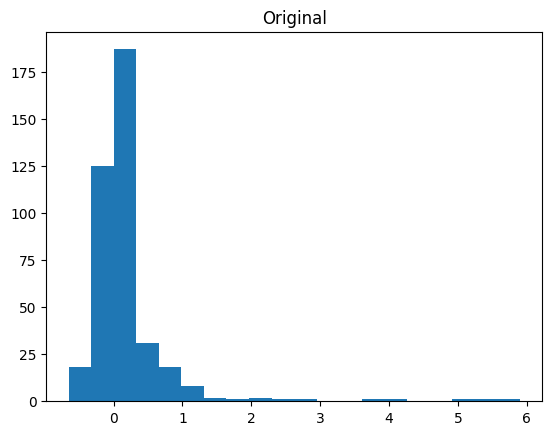

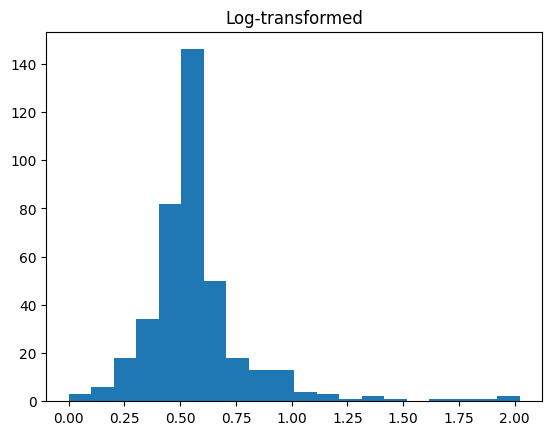

Log-tranformed
FN2O_L3.3_CUT_50_QCF0 was log-transformed


,timesince_soil_preparation,ts_0.3_gfXG_lag72h,wfps_0.05_gfXG_diff48h,wfps_0.15_gfXG_lag72h,n_decay_timed,timesince_fert,trt,FN2O_L3.3_CUT_50_QCF0
TIMESTAMP_MIDDLE,,,,,,,,
2023-11-17,31,NaN,NaN,NaN,0.0,30,0,0.615918
2023-11-17,31,NaN,NaN,NaN,0.0,30,1,0.506230
2023-11-18,32,NaN,NaN,NaN,0.0,30,1,0.696773
2023-11-18,32,NaN,NaN,NaN,0.0,30,0,0.559040
2023-11-19,33,NaN,-1.256492,NaN,0.0,30,1,0.541627
...,...,...,...,...,...,...,...,...
2024-08-19,15,22.443279,20.544650,36.871822,0.0,30,1,1.909369
2024-08-19,15,22.443279,20.544650,36.871822,0.0,30,0,2.021320
2024-08-20,16,22.228403,7.396426,35.248474,0.0,30,1,1.395045


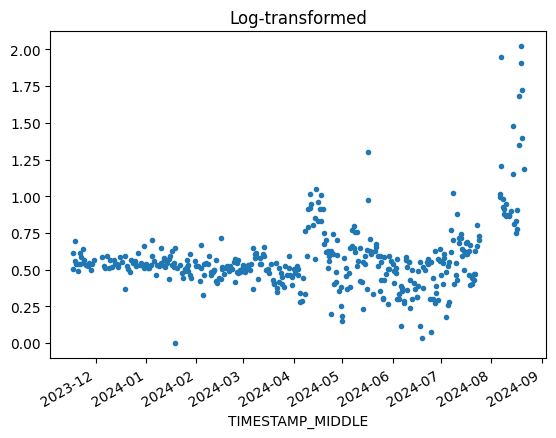

In [55]:
min_value = data[TARGET].min()

def log_transform(x):
    return np.log1p(x - min_value) if min_value < 0 else np.log1p(x)

def inverse_log_transform(x):
    return np.expm1(x) + min_value if min_value < 0 else np.expm1(x)

# Show histogram of non-tranformed and transformed TARGET
plt.hist(data[TARGET], bins=20)
plt.title('Original')
plt.show()
plt.hist(log_transform(data[TARGET]), bins=20)
plt.title('Log-transformed')
plt.show()

if LOG_TRANSFORM:
    print('Log-tranformed')
    data[TARGET] = log_transform(data[TARGET])
    print(f'{TARGET} was log-transformed')
    # Show log-transformed timeseries
    data[TARGET].plot(x_compat=True, style='.', title='Log-transformed');
else:
    print('\nLog-transformation of the target is not applied\n')

data

# CROSS-VAL SPLITS


Using time-blocks (4 records on average) splits for cross-validation



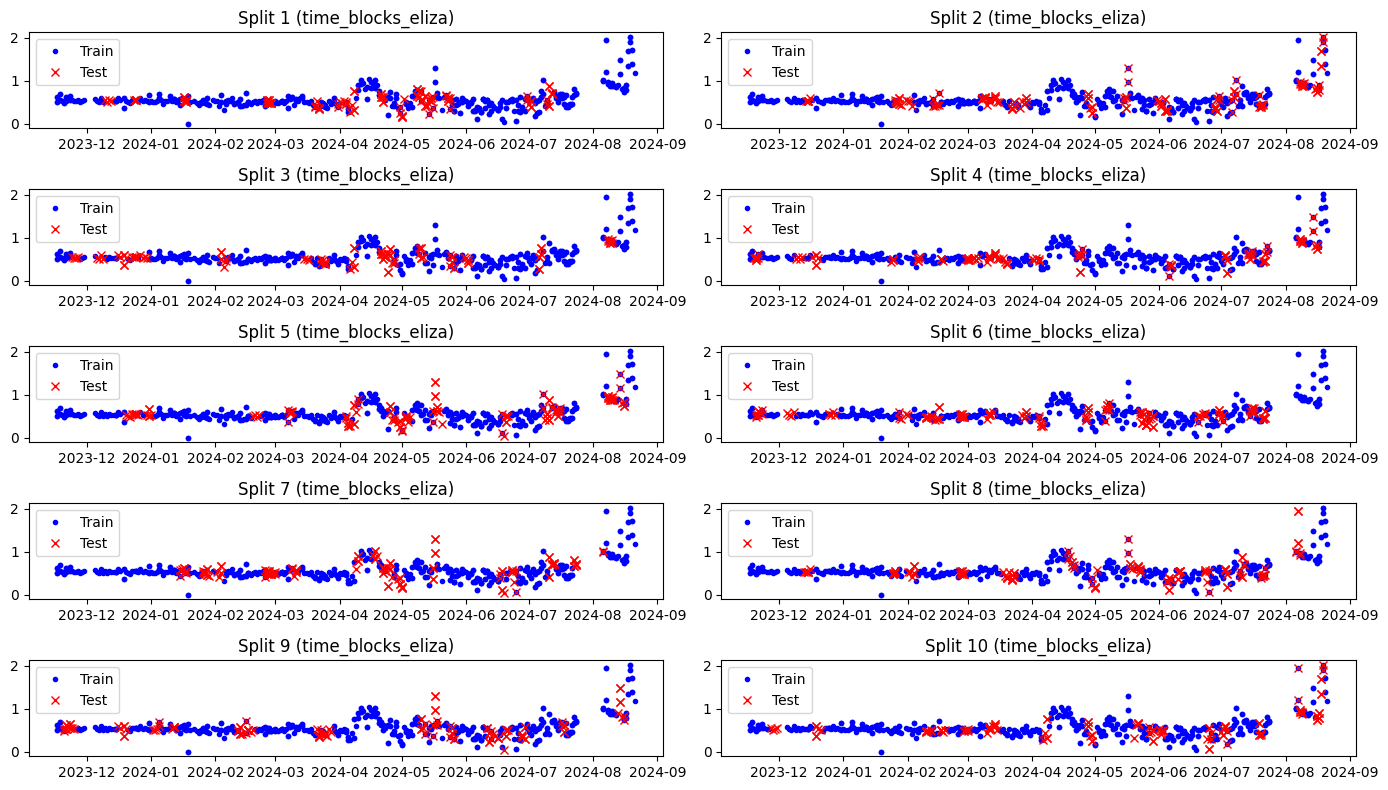

In [56]:
def create_splits(X, y, n_folds, test_size=0.2, random_state=42, n_bins=5):
    """Creates train-test splits using StratifiedShuffleSplit or StratifiedKFold with equal-width binning."""
    
    # Use pd.cut to create equal-width bins (avoids empty bins issue)
    y_binned = pd.cut(y, bins=n_bins, labels=False, include_lowest=True)

    # Select method for stratified splitting
    if CROSSVAL_SPLIT == "shuffle":
        splitter = StratifiedShuffleSplit(n_splits=n_folds, test_size=test_size, random_state=random_state)
        print('\nUsing stratified random splits for cross-validation\n')
    elif CROSSVAL_SPLIT == "kfold":
        splitter = StratifiedKFold(n_splits=n_folds, shuffle=False)
        print('\nUsing stratified kfold splits for cross-validation\n')

    # Generate train-test splits
    splits = [(train_idx, test_idx) for train_idx, test_idx in splitter.split(X, y_binned)]

    return splits

if CROSSVAL_SPLIT == 'time_blocks_eliza':
    block_size = 4 
    print(f'\nUsing time-blocks ({block_size} records on average) splits for cross-validation\n')
    def create_splits(X, y, n_folds, split=0.2, mean_block=block_size, min_block=1, random_state=42): # you can set mean block to mean_nan_size
        """Generates multiple train-test index splits using block-based cross-validation by varying the random seed."""
        splits = []
        total_test = round(len(X) * split)
        n_blocks = round(total_test/mean_block)

        if mean_block < min_block:
            raise ValueError("Min block size is too large for the number of blocks.")

        for fold in range(n_folds):
            np.random.seed(random_state + fold)  # Change seed for each fold
            
            tt = np.zeros(len(X))  # Array to store train-test assignments

            # Generate random block sizes with normal variation
            blocks = np.array([max(min_block, mean_block + round(v)) 
                            for v in np.random.normal(0, mean_block / 10, n_blocks)])

            # Randomly shuffle the starting positions of test blocks
            available_positions = np.arange(len(X))  # Possible start positions
            np.random.shuffle(available_positions)   # Shuffle them

            # Assign blocks sequentially based on shuffled positions
            assigned = set()
            for b in blocks:
                if len(assigned) >= total_test:
                    break
                # Pick a random starting position
                istart = np.random.choice(available_positions)
                iend = min(istart + int(b), len(X))

                # Ensure blocks don't overlap significantly
                assigned.update(range(istart, iend))
                tt[istart:iend] = 1

            train_idx = np.where(tt == 0)[0]
            test_idx = np.where(tt == 1)[0]
            
            splits.append((train_idx, test_idx))

        return splits

X = data.drop(columns=TARGET)
y = data[TARGET]
# Create the splits using StratifiedShuffleSplit
cross_val_splits = create_splits(X, y, n_folds=N_FOLDS)


# --- PLOT TRAIN-TEST SPLITS ---
n_rows = math.ceil(N_FOLDS / 2)  # Ensure enough rows for all splits
fig, axes = plt.subplots(n_rows, 2, figsize=(14, 8))
axes = axes.flatten()  # Flatten the axes array to make iteration easier

for i, (train_idx, test_idx) in enumerate(cross_val_splits):
    train_idx_mapped = X.iloc[train_idx].index
    test_idx_mapped = X.iloc[test_idx].index

    # Plot train and test points
    axes[i].plot(y.loc[train_idx_mapped].index, y.loc[train_idx_mapped], '.', label='Train', color="blue")
    axes[i].plot(y.loc[test_idx_mapped].index, y.loc[test_idx_mapped], 'x', label='Test', color="red")
    
    axes[i].set_title(f"Split {i + 1} ({CROSSVAL_SPLIT})")
    axes[i].legend()

# Hide unused subplots if n_folds is odd
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# CROSS-VALIDATION

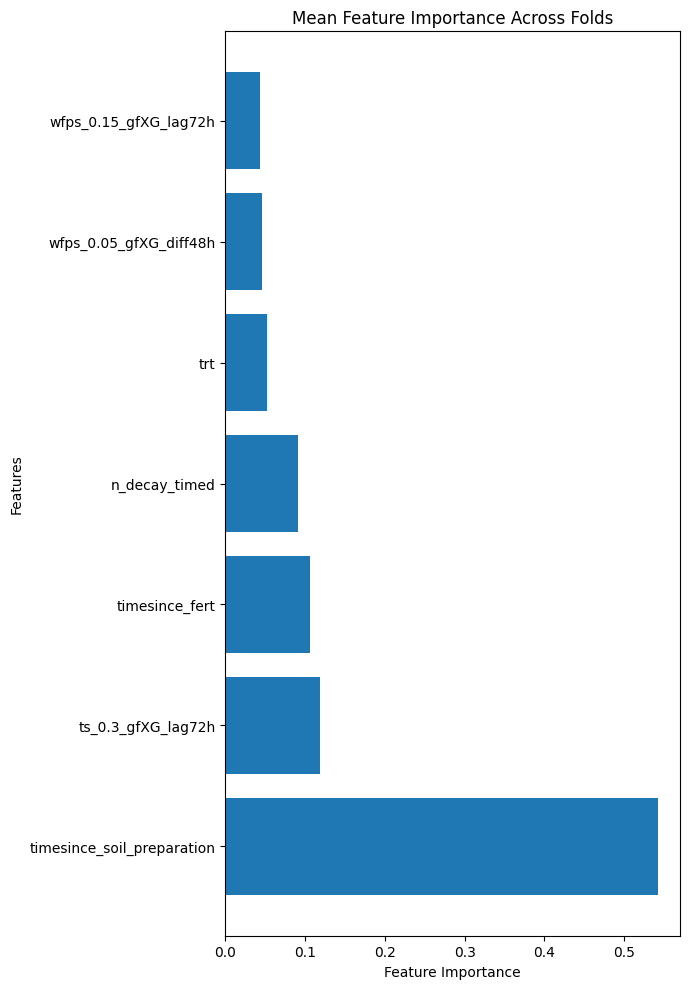

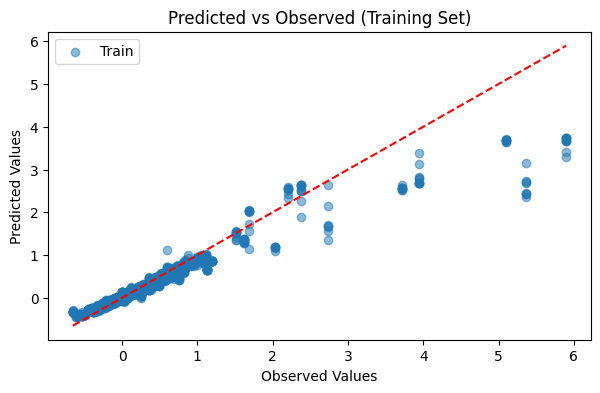

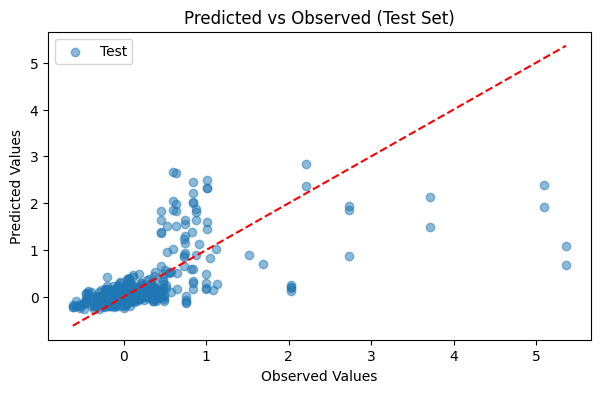

Train RMSE per fold: [0.2568 0.212  0.2442 0.2449 0.2399 0.2622 0.257  0.1994 0.2501 0.1958]
Mean Train RMSE: 0.2362
Test RMSE per fold: [0.2048 0.6367 0.2293 0.4176 0.5071 0.1733 0.3653 0.634  0.3776 0.6839]
Mean Test RMSE: 0.4230
Train R² per fold: [0.8695 0.8854 0.8827 0.8787 0.8779 0.8697 0.865  0.9031 0.8688 0.8739]
Mean Train R²: 0.8775
Test R² per fold: [ 0.2203  0.3387  0.2757 -0.0615  0.0725 -0.0457  0.2827  0.2673  0.4176
  0.541 ]
Mean Test R²: 0.2309


In [57]:
X = data.drop(columns=TARGET)
y = data[TARGET]

# Store results
rmse_train_values, rmse_test_values = [], []
r2_train_values, r2_test_values = [], []
feature_importances_folds = []
y_train_all, y_train_pred_all = [], []
y_test_all, y_pred_test_all = [], []

# Perform cross-validation
for train_idx, test_idx in cross_val_splits:  
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model.fit(X_train, y_train)
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    if LOG_TRANSFORM:
        y_train =  inverse_log_transform(y_train)
        y_test =  inverse_log_transform(y_test)
        y_train_pred =  inverse_log_transform(y_train_pred)
        y_test_pred =  inverse_log_transform(y_test_pred)

    # Store RMSE & R² for training and test sets
    rmse_train_values.append(root_mean_squared_error(y_train, y_train_pred))
    rmse_test_values.append(root_mean_squared_error(y_test, y_test_pred))
    r2_train_values.append(r2_score(y_train, y_train_pred))
    r2_test_values.append(r2_score(y_test, y_test_pred))

    # Store feature importances
    feature_importances_folds.append(model.feature_importances_)

    # Store predictions
    y_train_all.extend(y_train)
    y_train_pred_all.extend(y_train_pred)
    y_test_all.extend(y_test)
    y_pred_test_all.extend(y_test_pred)

# Compute mean feature importance across folds
feature_importances = np.nanmean(feature_importances_folds, axis=0)
# Sort feature importances
order = np.argsort(-feature_importances)  # Sort in descending order
feature_names = X_train.columns[order]  # Get feature names sorted by importance

# Plot sorted feature importances
fig, ax = plt.subplots(figsize=(7, 10))
ax.barh(feature_names, feature_importances[order])
ax.set_xlabel("Feature Importance")
ax.set_ylabel("Features")
ax.set_title("Mean Feature Importance Across Folds")
fig.tight_layout()
plt.show()

# Plot Predicted vs Observed (Training Set)
plt.figure(figsize=(7, 4))
plt.scatter(y_train_all, y_train_pred_all, alpha=0.5, label="Train")
plt.plot([min(y_train_all), max(y_train_all)], [min(y_train_all), max(y_train_all)], color='red', linestyle='--')
plt.xlabel("Observed Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Observed (Training Set)")
plt.legend()
plt.show()

# Plot Predicted vs Observed (Test Set)
plt.figure(figsize=(7, 4))
plt.scatter(y_test_all, y_pred_test_all, alpha=0.5, label="Test")
plt.plot([min(y_test_all), max(y_test_all)], [min(y_test_all), max(y_test_all)], color='red', linestyle='--')
plt.xlabel("Observed Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Observed (Test Set)")
plt.legend()
plt.show()

# Print RMSE and R² for both Training and Test sets
print(f"Train RMSE per fold: {np.array(rmse_train_values).round(4)}")
print(f"Mean Train RMSE: {np.mean(rmse_train_values):.4f}")
print(f"Test RMSE per fold: {np.array(rmse_test_values).round(4)}")
print(f"Mean Test RMSE: {np.mean(rmse_test_values):.4f}")

print(f"Train R² per fold: {np.array(r2_train_values).round(4)}")
print(f"Mean Train R²: {np.mean(r2_train_values):.4f}")
print(f"Test R² per fold: {np.array(r2_test_values).round(4)}")
print(f"Mean Test R²: {np.mean(r2_test_values):.4f}")


# FINAL MODEL

## Split train-test

Block splitting with test blocks that can vary of size and we can define the minimum size

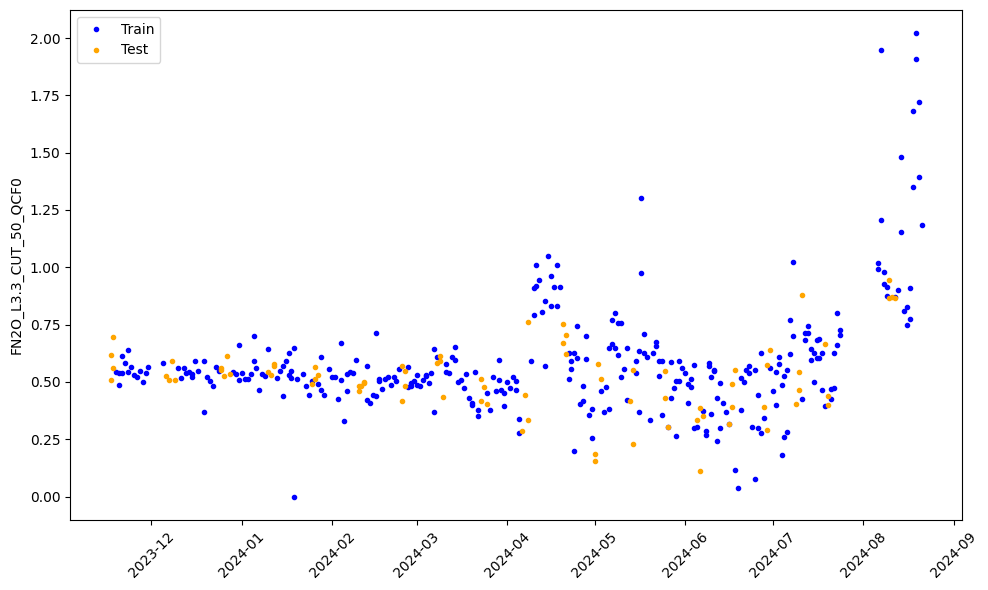

In [58]:
#mean_block = round(mean_nan_size)
mean_block = 4

def split_blocks(X, y, mean_block = mean_block, split=0.2, min_block=1):
       np.random.seed(42)  # Set seed for reproducibility
       tt = np.zeros(len(X)) # space for training/test assignments
       total_test = round(len(X)* split)
       n_blocks = round(total_test/mean_block)
       if mean_block<min_block:
              print("Error: Min block too long for this many blocks")
              return None
       # Vary the length of blocks around the mean (but not below the min)
       blocks = np.array([mean_block + round(v) for v in np.random.normal(0, mean_block/10, n_blocks)])
       blocks[blocks < min_block] = min_block
       # Assign the blocks
       for n, b in enumerate(blocks):
              istart = round(len(X)/(n_blocks))*(n-1)
              iend = istart+b
              tt[istart:iend] = 1
       X_train = X[tt==0]
       X_test = X[tt==1]
       y_train = y[tt==0]
       y_test = y[tt==1]
       # Return sorted data by index (timestamp)
       return X_train.sort_index(), X_test.sort_index(), y_train.sort_index(), y_test.sort_index(), tt

X = data.drop(columns=TARGET)
y = data[TARGET]
X_train, X_test, y_train, y_test, tt = split_blocks(X, y, mean_block=mean_block) # set number of blocks
              
# Check the split
fig, ax = plt.subplots(figsize=(10, 6))  # Adjusted size for better readability
ax.plot(y_train.index, y_train, ".", label="Train", color='blue')
ax.plot(y_test.index, y_test, ".", label="Test", color='orange')
ax.set_ylabel(TARGET)
plt.xticks(rotation=45)
ax.legend()
plt.tight_layout()

# Show the plot
plt.show()

## Model training and testing

[0]	validation_0-rmse:0.17142
[1]	validation_0-rmse:0.17080
[2]	validation_0-rmse:0.17026
[3]	validation_0-rmse:0.16970
[4]	validation_0-rmse:0.16917
[5]	validation_0-rmse:0.16872
[6]	validation_0-rmse:0.16825
[7]	validation_0-rmse:0.16786
[8]	validation_0-rmse:0.16737
[9]	validation_0-rmse:0.16706
[10]	validation_0-rmse:0.16676
[11]	validation_0-rmse:0.16624
[12]	validation_0-rmse:0.16575
[13]	validation_0-rmse:0.16528
[14]	validation_0-rmse:0.16477
[15]	validation_0-rmse:0.16425
[16]	validation_0-rmse:0.16384
[17]	validation_0-rmse:0.16346
[18]	validation_0-rmse:0.16307
[19]	validation_0-rmse:0.16260
[20]	validation_0-rmse:0.16221
[21]	validation_0-rmse:0.16163
[22]	validation_0-rmse:0.16131
[23]	validation_0-rmse:0.16103
[24]	validation_0-rmse:0.16071
[25]	validation_0-rmse:0.16034
[26]	validation_0-rmse:0.15977
[27]	validation_0-rmse:0.15934
[28]	validation_0-rmse:0.15898
[29]	validation_0-rmse:0.15857
[30]	validation_0-rmse:0.15811
[31]	validation_0-rmse:0.15771
[32]	validation_0-

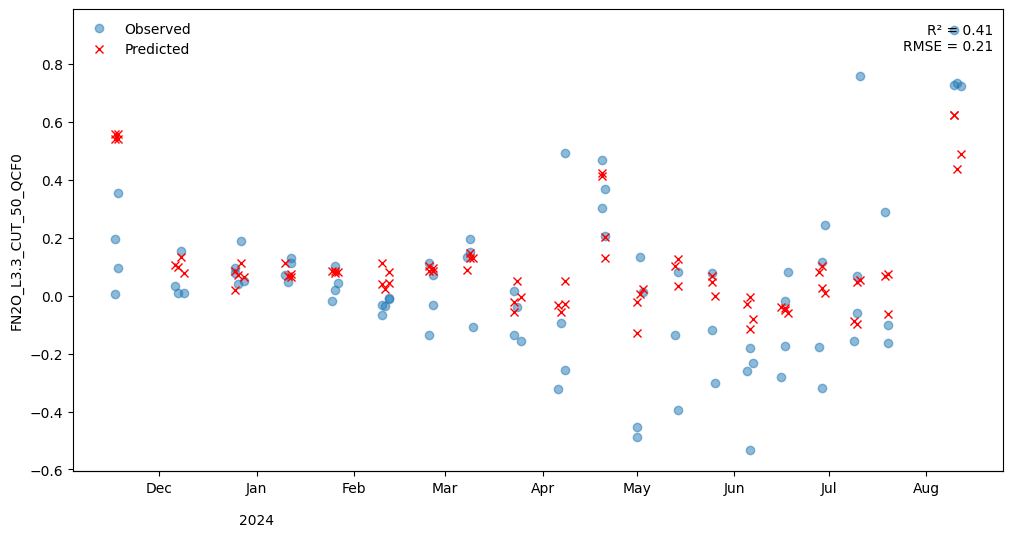

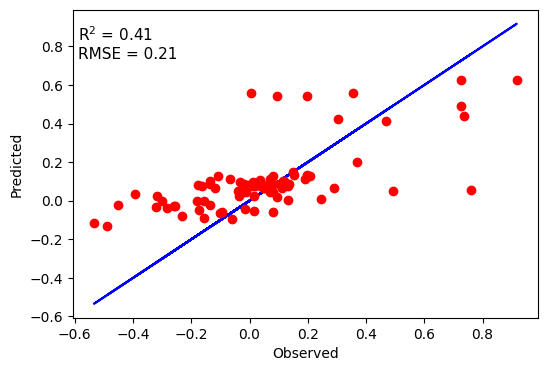

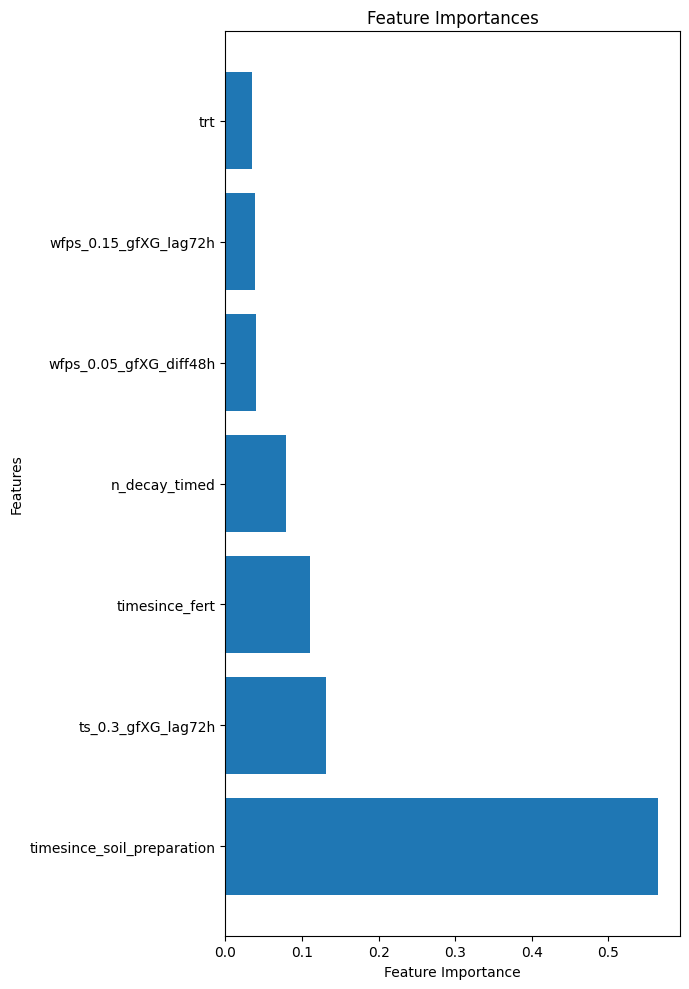

In [59]:
# Use early stopping if using XGBoost
model = RandomForestRegressor(**hyperparams, random_state=42, n_jobs=-1, early_stopping_rounds=10, eval_metric="rmse") if MODEL_TYPE == 'RandomForest' else XGBRegressor(**hyperparams, random_state=42, n_jobs=-1, early_stopping_rounds=10, eval_metric="rmse")

# Predict test set
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=True)
pred_train = model.predict(X_train)
pred_test = model.predict(X_test)

# Reverse the log transformation on the predictions and the original transformed data when the transformation was used
if LOG_TRANSFORM:
    pred_train = inverse_log_transform(pred_train) 
    pred_test = inverse_log_transform(pred_test)
    y_train = inverse_log_transform(y_train)
    y_test = inverse_log_transform(y_test)

# Calculate R-squared and Mean Squared Error (MSE) for the training set
r2_train = r2_score(y_train, pred_train)
print(f"R-squared (Training set): {r2_train:.4f}")
rmse_train = root_mean_squared_error(y_train, pred_train)
print(f"Root Mean Squared Error (Training set): {rmse_train:.4f}")
# Calculate R-squared and Mean Squared Error (MSE) for the test set
r2_test = r2_score(y_test, pred_test)
print(f"R-squared (Test set): {r2_test:.4f}")
rmse_test = root_mean_squared_error(y_test, pred_test)
print(f"Root Mean Squared Error (Test set): {rmse_test:.4f}")

# Time series plot
fig, ax = plt.subplots(1,figsize=(12, 6))
ax.plot(y_test.index, y_test,"o",label=("Observed"), alpha=0.5)
ax.plot(y_test.index, pred_test,"rx",label=("Predicted"))
# Format x-axis for months
ax.xaxis.set_major_locator(mdates.MonthLocator())  # Major ticks for months
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))  # Format as month abbreviation
# Add secondary x-axis for years
secax = ax.secondary_xaxis('bottom')
secax.xaxis.set_major_locator(mdates.YearLocator())  # Year ticks
secax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))  # Format as year
secax.tick_params(axis='x', length=0, pad=30)  # Add padding for better readability
# Add R2 and RMSE text
ax.text(0.99, 0.97, f'R² = {r2_test:.2f}\nRMSE = {rmse_test:.2f}',
        transform=ax.transAxes, va='top', ha='right')
ax.set_ylabel(TARGET)
ax.legend(frameon=False, loc="upper left")
# save fig
plt.savefig(f'plots/{TARGET}_gapfilling_testset_performance.png', dpi=300, bbox_inches="tight")
plt.show()
plt.close()

# Obs Vs predicted
fig, ax = plt.subplots(1,figsize=(6,4))
ax.plot(y_test,y_test,"b-")
ax.plot(y_test,pred_test,"ro")
# Add R2 and RMSE text
ax.text(0.01, 0.95, f'R$^{2}$ = {r2_test:.2f}\nRMSE = {rmse_test:.2f}',
        transform=ax.transAxes, va='top', fontsize=11)
ax.set_xlabel("Observed")
ax.set_ylabel("Predicted")
plt.show()

# Plot feature importances
importances = model.feature_importances_
sorted_idx = np.argsort(importances)[::-1]  # Sort descending
feature_names_sorted = X_train.columns[sorted_idx]

fig, ax = plt.subplots(figsize=(7, 10))
ax.barh(feature_names_sorted, importances[sorted_idx])
ax.set_xlabel("Feature Importance")
ax.set_ylabel("Features")
ax.set_title("Feature Importances")
plt.tight_layout()
plt.show()

# SHAP ANALYSIS

## RUN SHAP

In [60]:
# define background dataset
background_dataset = data_main[selected_features]

# Initialize the SHAP explainer
explainer = shap.TreeExplainer(model, data=background_dataset)

# Calculate SHAP values for each treatment separately
X_A = data_main[data_main['trt'] == 0][selected_features]
X_B = data_main[data_main['trt'] == 1][selected_features]
shap_values_A = explainer(X_A, check_additivity=True)
shap_values_B = explainer(X_B, check_additivity=True)

# Print the expected value
print("Baseline (expected value):", explainer.expected_value)
if LOG_TRANSFORM:
    print("Baseline without transformation (expected value):", inverse_log_transform(explainer.expected_value))

Baseline (expected value): 0.5852436589656559
Baseline without transformation (expected value): 0.1419836845751814


## SUMMARY PLOT

C:\Users\turcof\AppData\Local\Temp\ipykernel_20320\790593615.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_A, X_A, show=False)


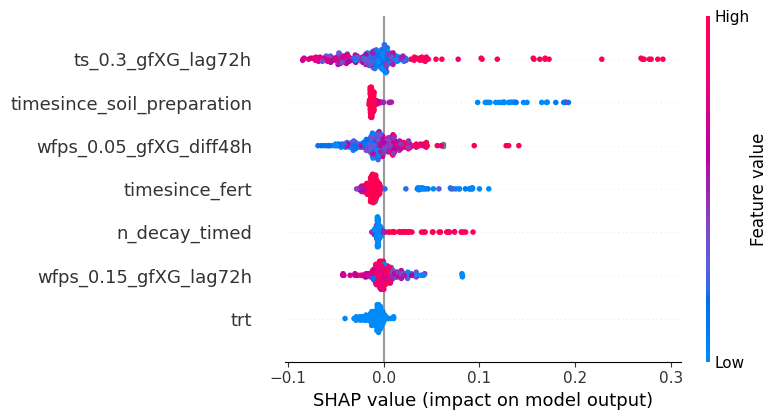

C:\Users\turcof\AppData\Local\Temp\ipykernel_20320\790593615.py:9: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_B, X_B, show=False)


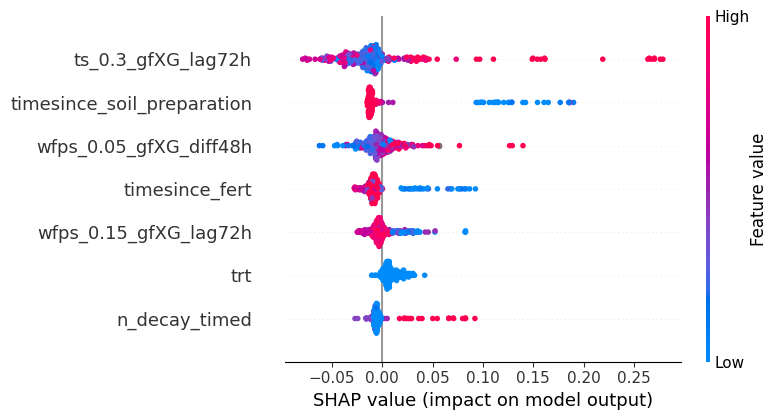

In [61]:
# SHAP summary plot
# Parcel A
fig = plt.figure()
shap.summary_plot(shap_values_A, X_A, show=False)
fig.savefig(f'plots/{TARGET}_shap_summary_plot_parcel_A.png', dpi=300, bbox_inches='tight')
plt.show()
# Parcel B
fig = plt.figure()
shap.summary_plot(shap_values_B, X_B, show=False)
fig.savefig(f'plots/{TARGET}_shap_summary_plot_parcel_B.png', dpi=300, bbox_inches='tight') 
plt.show()

## SHAP SCATTERPLOTS

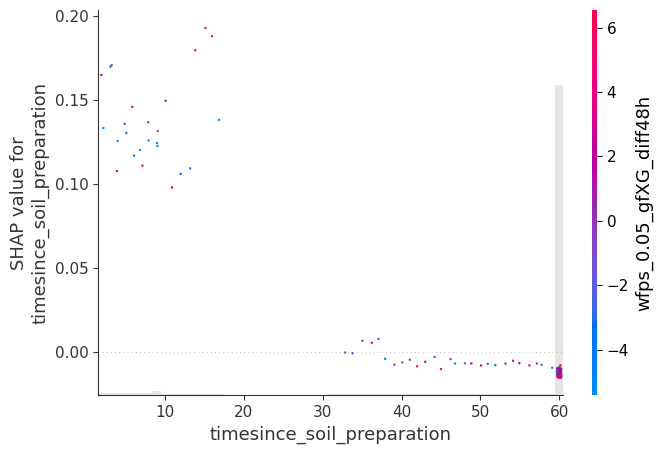

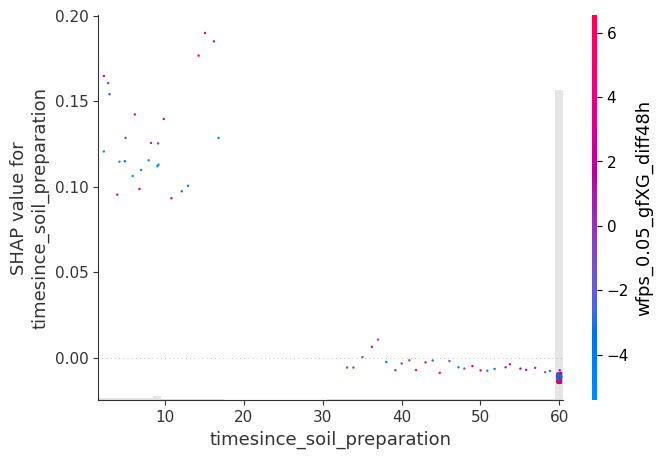

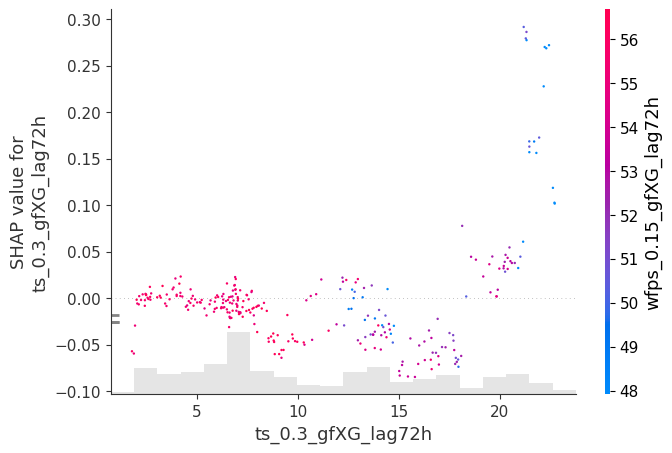

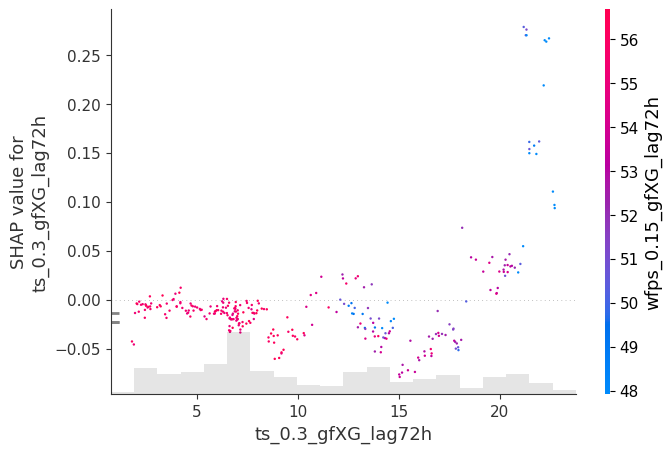

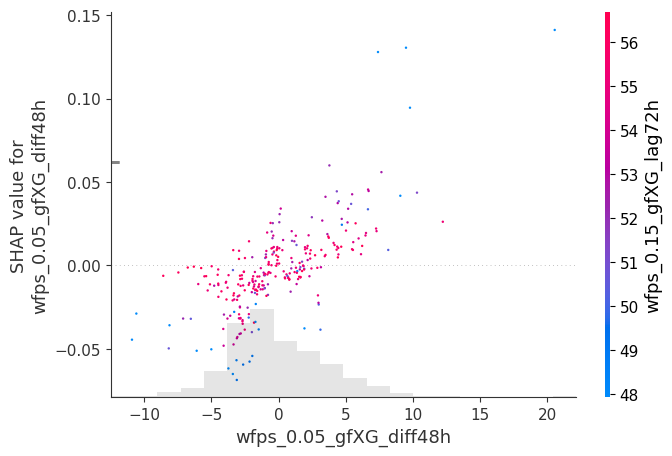

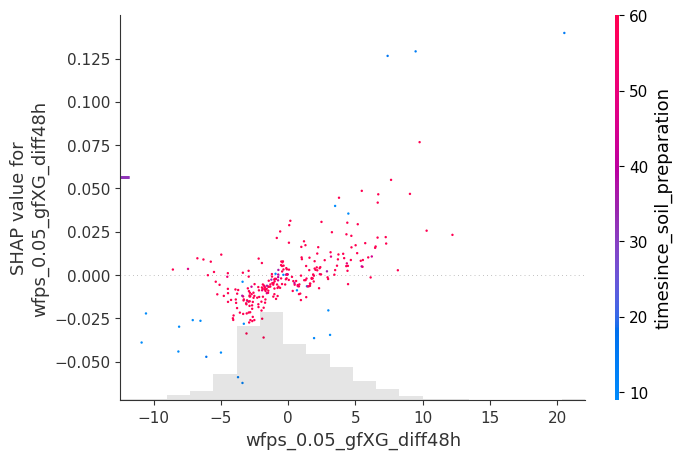

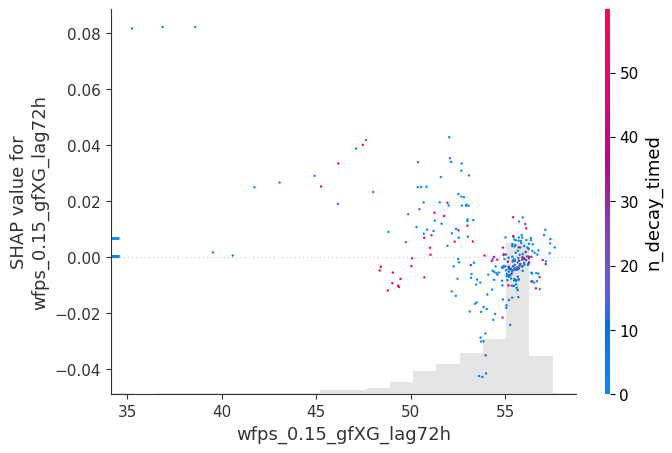

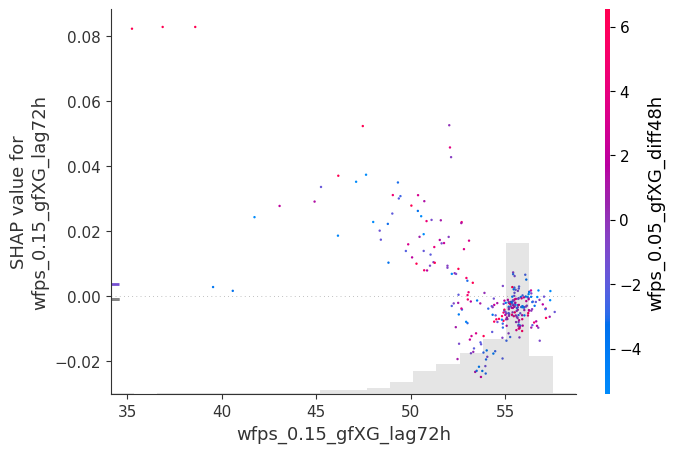

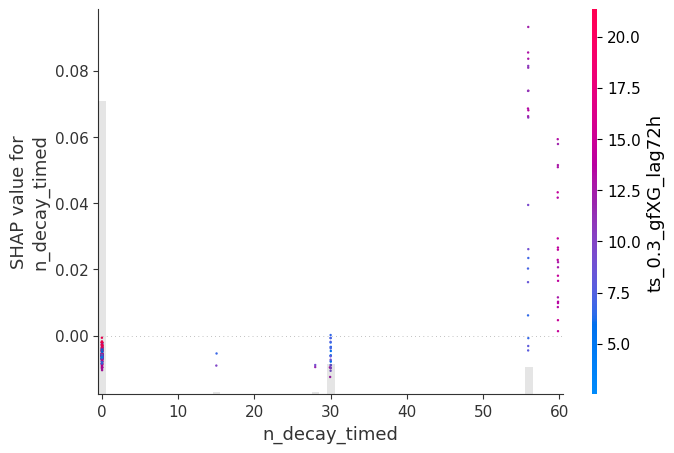

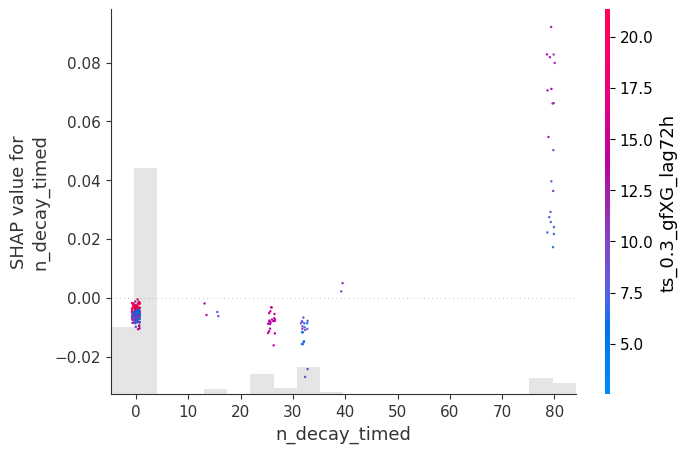

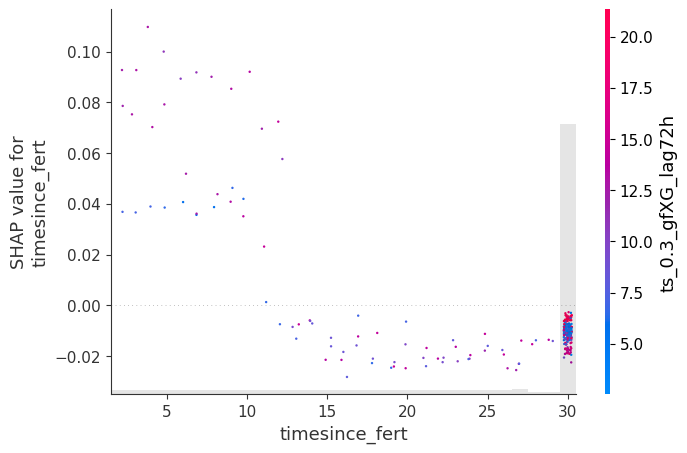

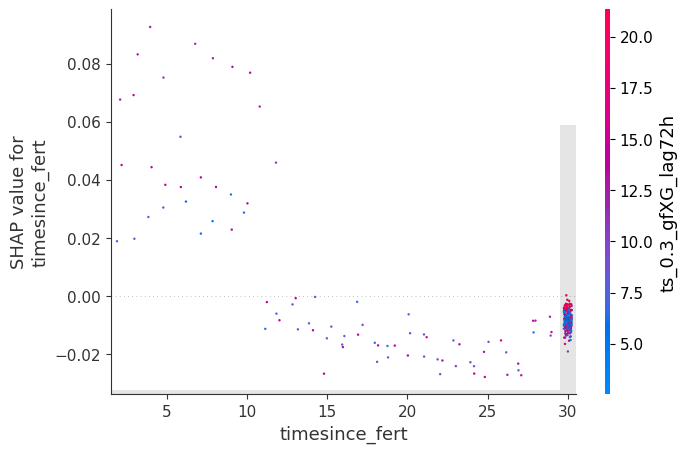

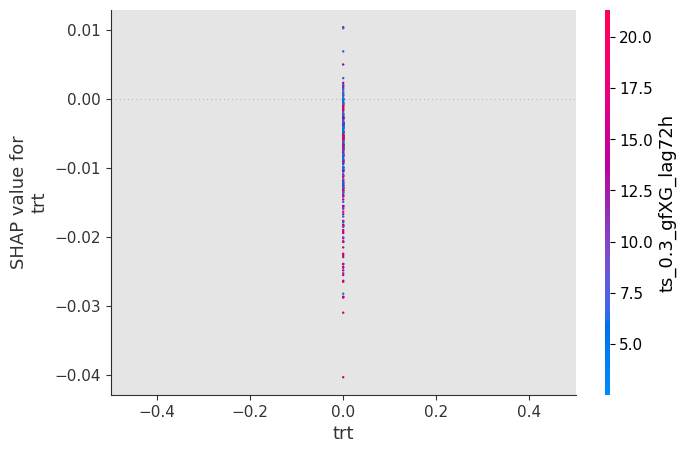

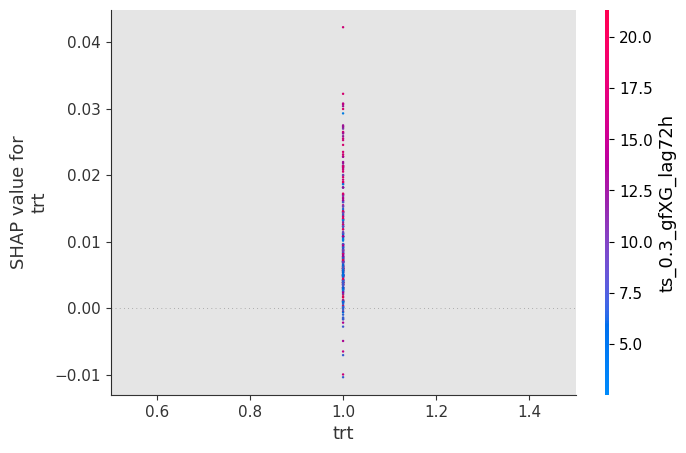

In [62]:
# Dependence plots
for var in X.columns:
    shap.plots.scatter(shap_values_A[:, var], dot_size=3, x_jitter=0.5, color=shap_values_A)
    plt.show()
    shap.plots.scatter(shap_values_B[:, var], dot_size=3, x_jitter=0.5, color=shap_values_B)
    plt.show()

# End of notebook

In [63]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2026-01-08 11:21:47
